In [1]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

sus_scrofa = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
sus_scrofa["Entry Name"] = sus_scrofa["Entry Name"].apply(lambda x: x.split("_")[0])
database_dict = get_database(sus_scrofa, key_col="Entry Name", value_col="Sequence")

datamatrix = pd.read_csv("../data/data.csv")

pnet = PeptideNetwork(
    datamatrix=datamatrix,
    protein_database=database_dict,
)

/Users/erikhartman/dev/peptide-networks/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading peptides...


In [2]:
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=3)
clusters.reindex()

Merged 41 clusters

Removed 0 clusters
Removed 857 clusters
Removed 303 clusters


In [3]:
from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/design_w_accidental.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
datamatrix = fm.datamatrix


nopython is set for njit and is ignored


In [34]:
from pepnets.LogoPlot import LogoPlot

lp = LogoPlot(datamatrix, database_dict, entity="Cluster")

Boolean Series key will be reindexed to match DataFrame index.
Boolean Series key will be reindexed to match DataFrame index.


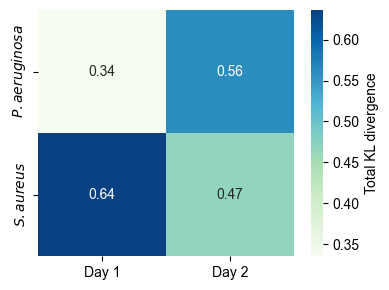

In [42]:
import seaborn as sns

design = pd.read_csv("../data/design_w_accidental.csv")


def get_div(design, background_group, test_group):
    divs = []
    background_samples = design[design["day"].isin(["Day 1", "Day 2"])][
        design["group"] == background_group
    ]["sample"].tolist()
    days = ["Day 1", "Day 2"]
    for day in days:
        design_day = design[design["day"] == day]
        test_samples = design_day[design_day["group"] == test_group]["sample"].tolist()

        height = lp.get_letter_heights(test_samples, background_samples)
        divs.append(height.sum(axis=1).sum())
    return divs


pa_divs = get_div(
    design,
    background_group="P. aeruginosa",
    test_group="Accidental double infection",
)
sa_divs = get_div(
    design, background_group="S. aureus", test_group="Accidental double infection"
)

divs = pd.DataFrame(
    [pa_divs, sa_divs],
    index=[r"$P. aeruginosa$", r"$S. aureus$"],
    columns=["Day 1", "Day 2"],
)
plt.figure(figsize=(4, 3))
sns.heatmap(
    divs,
    annot=True,
    cmap="GnBu",
    cbar_kws={"label": "Total KL divergence"},
)
plt.tight_layout()
divs.to_csv("source_data/5g.csv")
plt.savefig("figures/main_figures/5g.svg", bbox_inches="tight")

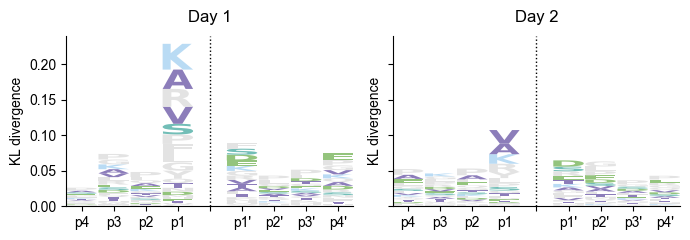

In [40]:
test_group = "Accidental double infection"

positions = ["p4", "p3", "p2", "p1", " ", "p1'", "p2'", "p3'", "p4'"]
max_y = 0
background_samples = design[design["group"].isin(["S. aureus"])]["sample"].tolist()
days = ["Day 1", "Day 2"]
heights = []
fig, axs = plt.subplots(1, len(days), figsize=(7, 2.5), sharey=True)
for d, day in enumerate(days):
    design_day = design[design["day"] == day]
    test_samples = design_day[design_day["group"] == test_group]["sample"].tolist()
    height = lp.get_letter_heights(test_samples, background_samples)

    xticks = height.index
    lp.plot(height, ax=axs[d])
    sns.despine(ax=axs[d])
    axs[d].axvline(0, color="k", linewidth=1, linestyle=":")
    axs[d].set_ylabel("KL divergence")
    axs[d].set_xticks(list(range(-4, 5)), positions)
    height["day"] = [day] * len(height.index)
    heights.append(height)

plt.ylim([0, 0.24])
for ax, col in zip(axs, days):
    ax.annotate(
        col,
        xy=(0.5, 1),
        xytext=(0, 10),
        xycoords="axes fraction",
        textcoords="offset points",
        size="large",
        ha="center",
        va="baseline",
    )
plt.tight_layout()
pd.concat(heights).to_csv("source_data/5e.csv")
plt.savefig("figures/main_figures/5e.svg", bbox_inches="tight")

Mean of empty slice


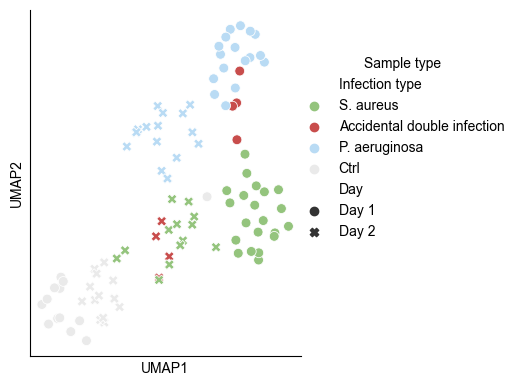

In [7]:
from umap import UMAP
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from pepnets.palette import group_palette

design = pd.read_csv("../data/design_w_accidental.csv").reset_index()
topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)
design = design[design["group"].isin(["S. aureus", "Ctrl", "P. aeruginosa", "Accidental double infection"])]
samples = design["sample"]
feature_matrix = topn.T.loc[samples].fillna(0)
X = feature_matrix.values
scaler = StandardScaler()
X = scaler.fit_transform(X)
days = design["day"]
y = np.array(design["group"])

le = LabelEncoder()
y_int = le.fit_transform(y)

reducer = UMAP()
X_r = reducer.fit_transform(X)

df = pd.DataFrame(X_r)
df["Day"] = days
df["Infection type"] = y

fig = plt.figure(figsize=(3.5, 4.5))

sns.scatterplot(
    df, x=0, y=1, hue="Infection type", palette=group_palette, style="Day", s=50
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.xticks([])
plt.yticks([])
sns.despine()

plt.legend(
    loc="upper left", frameon=False, bbox_to_anchor=(0.95, 0.9), title="Sample type"
)
df.to_csv("source_data/5c.csv")
plt.savefig("figures/main_figures/5c.svg", bbox_inches="tight")

Mean of empty slice
Passing `palette` without assigning `hue` is deprecated.


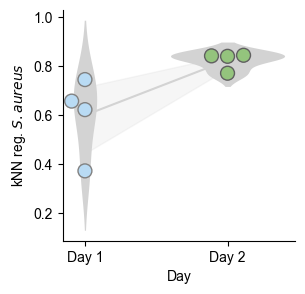

In [8]:
topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
    .fillna(0)
)

training_groups = ["S. aureus", "P. aeruginosa"]
testing_groups = ["Accidental double infection"]


training_samples = design[design["group"].isin(training_groups)]["sample"]
testing_samples = design[design["group"].isin(testing_groups)]["sample"]

X = topn.T.values

scaler = StandardScaler()
X = scaler.fit_transform(X)

topn = pd.DataFrame(X, columns=topn.index, index=topn.columns)

X_train = topn.loc[training_samples]
X_test = topn.loc[testing_samples]

y_train = np.array(design[design["group"].isin(training_groups)]["group"])
le = LabelEncoder()
y_int = le.fit_transform(y_train)
days = design[design["group"].isin(testing_groups)]["day"]


from sklearn.neighbors import KNeighborsRegressor


knn = KNeighborsRegressor(n_neighbors=30, weights="distance")

knn.fit(X_train, y_int)
knn_pred = knn.predict(X_test)


plot_df = pd.DataFrame({"day": days, "knn": knn_pred})

plt.figure(figsize=(3, 3))

sns.swarmplot(
    plot_df,
    y="knn",
    x="day",
    palette=[group_palette["P. aeruginosa"], group_palette["S. aureus"]],
    size=10,
    linewidth=1,
)

sns.violinplot(plot_df, y="knn", x="day", color="lightgray", linewidth=0)


sns.lineplot(plot_df, y="knn", x="day", color="lightgray")

plt.xlabel("Day")
plt.ylabel(r"kNN reg. $S. aureus$")
sns.despine()
plot_df.to_csv("source_data/5f.csv")
plt.savefig("figures/main_figures/5f.svg", bbox_inches="tight")

In [5]:
from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/design_w_accidental.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
#topn_de = fm.get_topn_de(group_a="P. aeruginosa", group_b="S. aureus", metric="pval")
topn_de = fm.get_topn().groupby("Cluster", as_index=False).mean(numeric_only=True)

from dpks import QuantMatrix

qm = QuantMatrix(
    topn_de,
    design,
)
qm.compare(
    method="linregress",
    min_samples_per_group=3,
    level="Cluster",
    comparisons=[("P. aeruginosa", "S. aureus")],
    multiple_testing_correction_method="fdr_tsbh",
)
df_compare_sa_pa = qm.to_df()

Mean of empty slice


In [6]:
design = pd.read_csv("../data/design_w_accidental.csv")
design = design[design["group"] == "Accidental double infection"]
design["group"] = design["day"]
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
#topn_de = fm.get_topn_de(group_a="Day 1", group_b="Day 2", metric="pval")
topn_de = fm.get_topn().groupby("Cluster", as_index=False).mean(numeric_only=True)

qm = QuantMatrix(
    topn_de,
    design,
)
qm.compare(
    method="linregress",
    min_samples_per_group=3,
    level="Cluster",
    comparisons=[("Day 1", "Day 2")],
    multiple_testing_correction_method="fdr_tsbh",
)
df_compare_d1_d2 = qm.to_df()
df_compare_d1_d2

Mean of empty slice


,Cluster,Start,End,Sample 17 Day 1,Sample 18 Day 1,Sample 19 Day 1,Sample 20 Day 1,Sample 21 Day 1,Sample 22 Day 1,Sample 23 Day 1,...,CorrectedPValueDay 1-Day 2,-Log10CorrectedPValueDay 1-Day 2,Sample 6 Day 1,Sample 7 Day 1,Sample 8 Day 1,Sample 9 Day 1,Sample 6 Day 2,Sample 7 Day 2,Sample 8 Day 2,Sample 9 Day 2
0,6PGD_0,233.000000,250.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1AT_0,337.800000,357.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1AT_1,407.400000,421.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1AT_2,412.333333,421.000000,NaN,NaN,NaN,NaN,4.359920,NaN,0.158180,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.140064
4,ACRO_0,346.000000,354.875000,10.644212,10.230357,10.131574,6.155618,NaN,NaN,9.099990,...,NaN,NaN,4.349197,7.132024,4.880781,8.852556,NaN,NaN,NaN,10.804691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,VTNC_2,110.800000,126.600000,NaN,7.260470,13.511411,8.969830,12.798494,6.887282,9.285677,...,0.762491,0.117765,10.752335,11.409621,3.297330,10.960312,8.490803,NaN,8.464856,5.903247
791,VTNC_3,207.000000,220.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
792,VTNC_4,220.000000,233.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
793,VTNC_5,282.000000,295.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


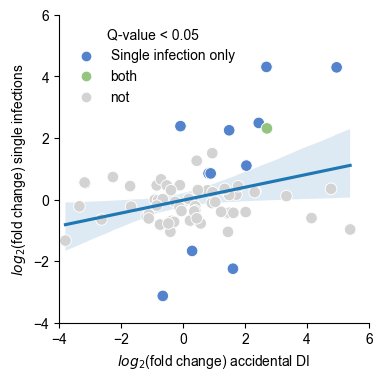

In [29]:
import seaborn as sns

df_compare_d1_d2 = df_compare_d1_d2[
    [
        "Cluster",
        "Log2FoldChangeDay 1-Day 2",
        "DEScoreDay 1-Day 2",
        "CorrectedPValueDay 1-Day 2",
        "PValueDay 1-Day 2",
    ]
]
df_compare_sa_pa = df_compare_sa_pa[
    [
        "Cluster",
        "Log2FoldChangeP. aeruginosa-S. aureus",
        "DEScoreP. aeruginosa-S. aureus",
        "CorrectedPValueP. aeruginosa-S. aureus",
        "PValueP. aeruginosa-S. aureus",
    ]
]

df_merge = df_compare_d1_d2.merge(
    df_compare_sa_pa, left_on="Cluster", right_on="Cluster"
)
df_merge["accidental_significant"] = df_merge["CorrectedPValueDay 1-Day 2"].apply(
    lambda x: "significant" if x < 0.05 else "not"
)
df_merge["pure_significant"] = df_merge["CorrectedPValueP. aeruginosa-S. aureus"].apply(
    lambda x: "significant" if x < 0.05 else "not"
)
df_merge["Q-value <0.05"] = df_merge.apply(
    lambda x: (
        "both"
        if (
            x["CorrectedPValueDay 1-Day 2"] < 0.05
            and x["CorrectedPValueP. aeruginosa-S. aureus"] < 0.05
        )
        else (
            "Accidental only"
            if x["CorrectedPValueDay 1-Day 2"] < 0.05
            else (
                "Single infection only"
                if x["CorrectedPValueP. aeruginosa-S. aureus"] < 0.05
                else "not"
            )
        )
    ),
    axis=1,
)
df_merge["Protein"] = df_merge["Cluster"].apply(lambda x: x.split("_")[0])
df_merge.sort_values("Q-value <0.05", inplace=True)

plt.figure(figsize=(4, 4))

g = sns.regplot(
    df_merge,
    x="Log2FoldChangeDay 1-Day 2",
    y="Log2FoldChangeP. aeruginosa-S. aureus",
)
sns.scatterplot(
    df_merge,
    x="Log2FoldChangeDay 1-Day 2",
    y="Log2FoldChangeP. aeruginosa-S. aureus",
    hue="Q-value <0.05",
    palette={
        "Accidental only": group_palette["Accidental double infection"],
        "not": "lightgray",
        "Single infection only": "#5283cc",
        "both": group_palette["S. aureus"],
    },
    s=70,
)
plt.xlabel(r"$log_2$(fold change) accidental DI")
plt.ylabel(r"$log_2$(fold change) single infections")
plt.xlim([-4, 6])
plt.ylim([-4, 6])
plt.legend(frameon=False, title="Q-value < 0.05")
sns.despine()
plt.savefig("figures/main_figures/5d.svg", bbox_inches="tight")
df_merge.to_csv("source_data/5d.csv")

In [ ]:
df_merge[df_merge["Q-value <0.05"] == "both"][
    [
        "Cluster",
        "Log2FoldChangeDay 1-Day 2",
        "Log2FoldChangeP. aeruginosa-S. aureus",
        "Q-value <0.05",
    ]
]

,Cluster,Log2FoldChangeDay 1-Day 2,Log2FoldChangeP. aeruginosa-S. aureus,Q-value <0.05
367,HBA_1,2.702873,2.30951,both


In [ ]:
clusters.get_cluster_by_id("HBA_1").end

16